In [9]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import os
import seaborn as sns

#  Results - Diffusion-Based Data Augmentation: Parameter-Efficient Fine-Tuning of Cheff for Rare Pathologies
This notebook provides a summary of the project's results, including the fine-tuning of the Cheff diffusion model, the performance of downstream pathology classifiers, and an analysis of synthetic data filtering strategies.

## 1. Cheff LoRA Finetuning

The [Cheff](https://github.com/saiboxx/cheff) diffusion model was pretrained on the large-scale adult chest X-ray dataset MIMIC-CXR. [VinDr-PCXR](https://physionet.org/content/vindr-pcxr/1.0.0/) is a pediatric dataset with a fundamentally different imaging distribution (patient size, projection geometry, pathology prevalence) and a relatively small number of annotated training images. This creates a dual challenge: a **domain gap** (adult → pediatric) and **data scarcity** for rare pathologies such as Bronchitis and Bronchiolitis.

To bridge this gap without re-training the full model, we applied **Parameter-Efficient Fine-Tuning (PEFT)** via Low-Rank Adaptation (LoRA). LoRA injects trainable low-rank decomposition matrices into the attention projection layers (`to_q`, `to_k`, `to_v`, `to_out.0`) of Cheff's UNet, with rank $r = 16$ and scaling factor $\alpha = 32$. All original model weights are frozen; only the LoRA adapter weights are updated during training, corresponding to less than 1% of total model parameters.

The adapter was trained for **15 epochs** on the VinDr-PCXR training split using the standard diffusion denoising objective.

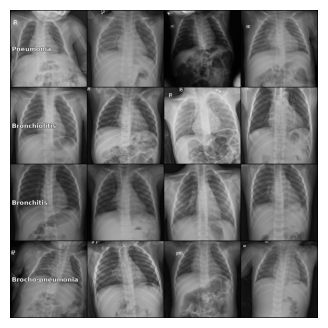

In [10]:
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread('cheff_lora_pcxr.png'))
plt.axis('off')
plt.show()

*Sample pediatric chest X-ray generated by the LoRA-adapted Cheff model, conditioned on the "Pneumonia" prompt. The image exhibits plausible pediatric chest anatomy, including proportional cardiac silhouette and lung fields typical of younger patients, demonstrating that fine-tuning has shifted Cheff's output distribution toward the pediatric domain.*

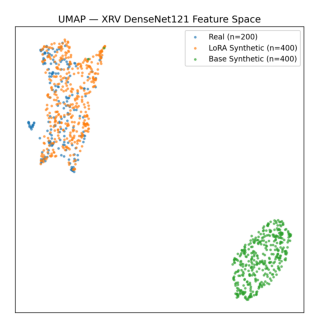

In [ ]:
plt.figure(figsize=(4, 4))
plt.imshow(plt.imread('finetune_viz/umap.png'))
plt.axis('off')
plt.show()

### Feature Distribution Analysis

To quantitatively assess the domain adaptation, we extract feature embeddings from a DenseNet121 model pretrained on multi-label chest X-ray classification (torchxrayvision) and project them to 2D via UMAP. Three sets of images are compared: **real** VinDr-PCXR images, images generated by the **base** (un-adapted) Cheff model, and images generated by the **LoRA-adapted** model.

The UMAP plot above shows that LoRA-generated images form a cluster that closely overlaps with the real image distribution. In contrast, images from the base model occupy a distinct and largely disjoint region of feature space, confirming that the un-adapted model produces images far outside the pediatric imaging manifold.

In [11]:
fdd_df = pd.read_csv('finetune_viz/fdd.csv')
fdd_df['comparison'] = fdd_df['comparison'].map({
    'real_vs_lora': 'Real vs LoRA',
    'real_vs_base': 'Real vs Base',
    'real_self_check': 'Real vs Real (self-check)',
})
fdd_df.columns = ['Comparison', '# Real', '# Synthetic', 'FDD']
display(fdd_df.style.hide(axis='index').format({'FDD': '{:.4f}'}))

Comparison,# Real,# Synthetic,FDD
Real vs LoRA,400,400,1.6111
Real vs Base,400,400,17.8052
Real vs Real (self-check),400,400,0.6635


The **Fréchet DenseNet Distance (FDD)** is computed as the Fréchet distance between Gaussian fits of the DenseNet121 feature distributions — analogous to FID but using a task-specific feature extractor more appropriate for medical imaging.

The LoRA-adapted model achieves an FDD of **1.61** against the real distribution, compared to **17.81** for the base model — a reduction of approximately **90%**. The self-check FDD of **0.66** (computed between two disjoint halves of the real dataset) establishes a near-zero lower bound, confirming the metric behaves correctly. Together, these results quantitatively validate the qualitative observation from the UMAP plot: LoRA fine-tuning successfully closes the domain gap between the adult-pretrained generative model and the pediatric imaging distribution.

## 2. Classifier Test Performance
We evaluate the classification performance across three experimental setups to determine the impact of diffusion-based data augmentation:

*   **Baseline**: Model trained solely on the VinDr-PCXR pediatric dataset.
*   **Synthetic**: Model trained on the dataset augmented with unfiltered synthetic images generated from the LoRA-adapted Cheff model.
*   **Synthetic Filtered**: Model trained with real data augmented by synthetic samples selected via an Oracle-based filtering strategy.

In [38]:
def load_metrics(path):
    with open(path, 'r') as f:
        return json.load(f)

runs_root = '../classifier/runs'
baseline_metrics = load_metrics(os.path.join(runs_root, 'baseline_slurm_ref/metrics.json'))
synthetic_metrics = load_metrics(os.path.join(runs_root, 'synthetic_slurm_ref/metrics.json'))
synthetic_filtered_metrics = load_metrics(os.path.join(runs_root, 'synthetic_filtered_slurm_ref/metrics.json'))

df_baseline = pd.DataFrame(baseline_metrics).T
df_synthetic = pd.DataFrame(synthetic_metrics).T
df_filtered = pd.DataFrame(synthetic_filtered_metrics).T

auroc_comparison = pd.DataFrame({
    'Baseline': df_baseline['auroc'],
    'Synthetic': df_synthetic['auroc'],
    'Synthetic Filtered': df_filtered['auroc']
}).T

auroc_comparison['Mean AUC'] = auroc_comparison.mean(axis=1)

print("AUROC Comparison: Pathologies and Macro Mean")
display(auroc_comparison.style.highlight_max(axis=0, color='grey'))

AUROC Comparison: Pathologies and Macro Mean


,No finding,Bronchitis,Brocho-pneumonia,Bronchiolitis,Pneumonia,Other disease,Mean AUC
Baseline,0.719009,0.686295,0.769539,0.696948,0.763787,0.622819,0.709733
Synthetic,0.711826,0.669345,0.762802,0.656287,0.748299,0.592621,0.690197
Synthetic Filtered,0.718772,0.695026,0.770509,0.698444,0.758702,0.635549,0.712834


### Performance Analysis
The results show that augmentation with the unfiltered synthetic data led to a performance decrease compared to the baseline. This is likely due to the noise inherent in the sampling of generative models. However, by employing Oracle filtering, performance could be recovered, matching or even slightly exceeding the baseline for specific pathologies. These results emphasize the importance of filtering the generated synthetic data.

## 3. Synthetic Filtering Analysis

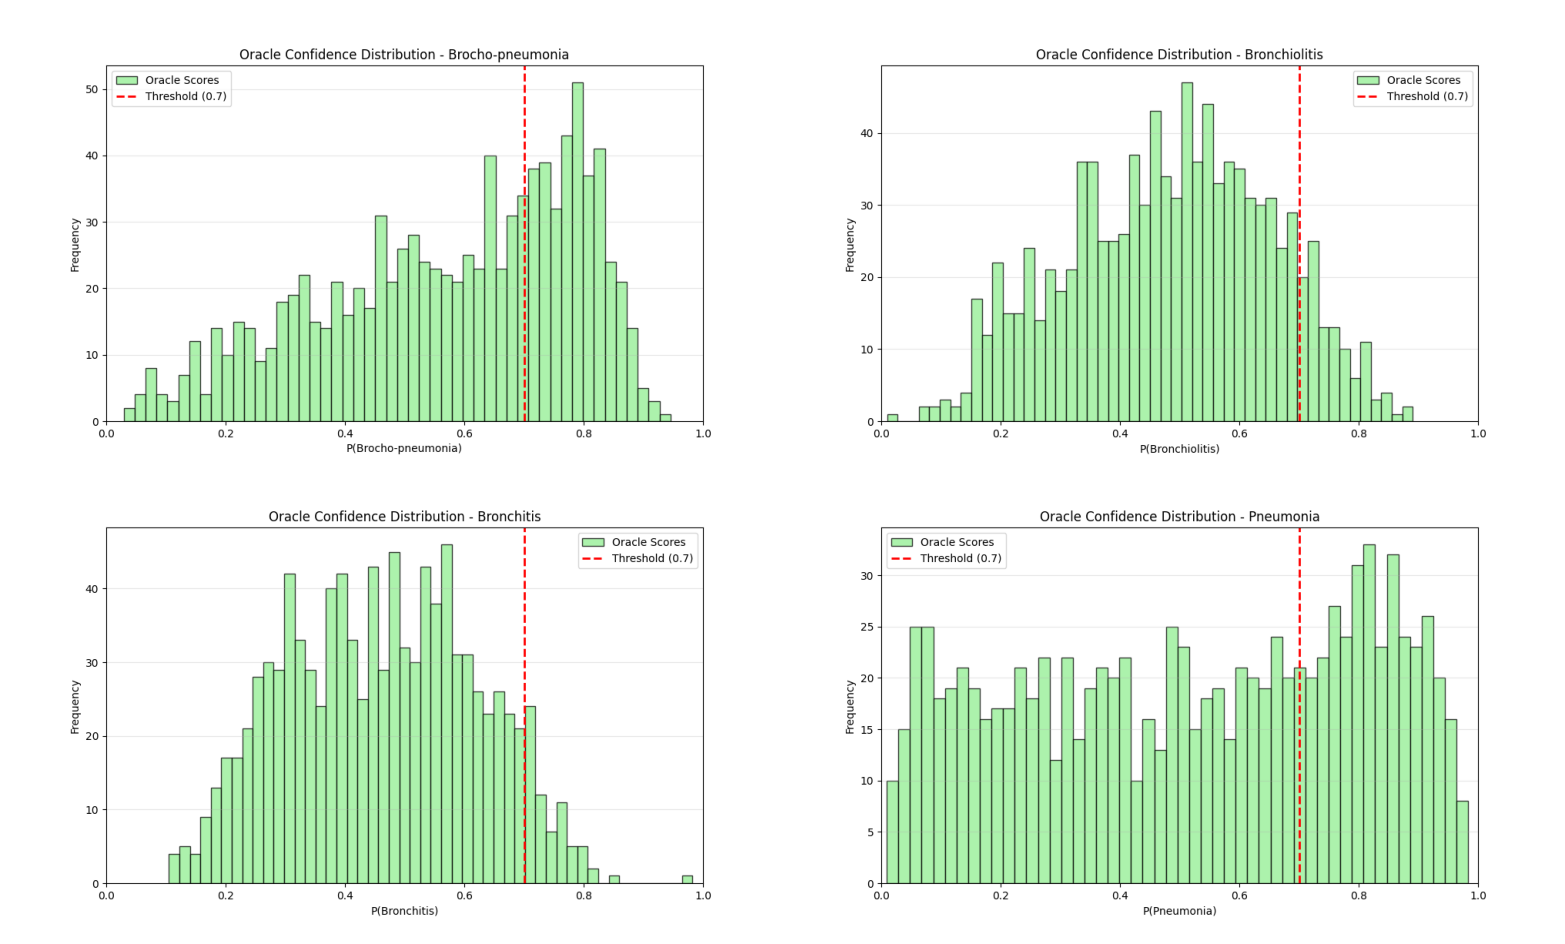

In [37]:
import matplotlib.pyplot as plt
import os

filter_runs_dir = '../classifier/runs/synthetic_filtered_slurm_ref'
oracle_images = [
    'oracle_distribution_Brocho-pneumonia.png',
    'oracle_distribution_Bronchiolitis.png',
    'oracle_distribution_Bronchitis.png',
    'oracle_distribution_Pneumonia.png'
]

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for i, img_name in enumerate(oracle_images):
    img_path = os.path.join(filter_runs_dir, img_name)
    img = plt.imread(img_path)
    axes[i].imshow(img)
    axes[i].axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

The distribution of predicted probabilities for synthetic data varies significantly across pathologies. This likely stems from two factors: the relative complexity of synthesizing (or detecting) specific pathological features, and the inductive biases of the pretrained torchxrayvision classifier, which may be more attuned to certain conditions like Pneumonia due to its original training distribution.

Notably, Bronchitis exhibited the most substantial improvement in test performance. This is particularly striking given the stringent filtering used for this class, where only 108 synthetic samples were utilized for augmentation.

## 4. Classifier Training Stability
Finally, we visualize the validation AUC and training loss curves

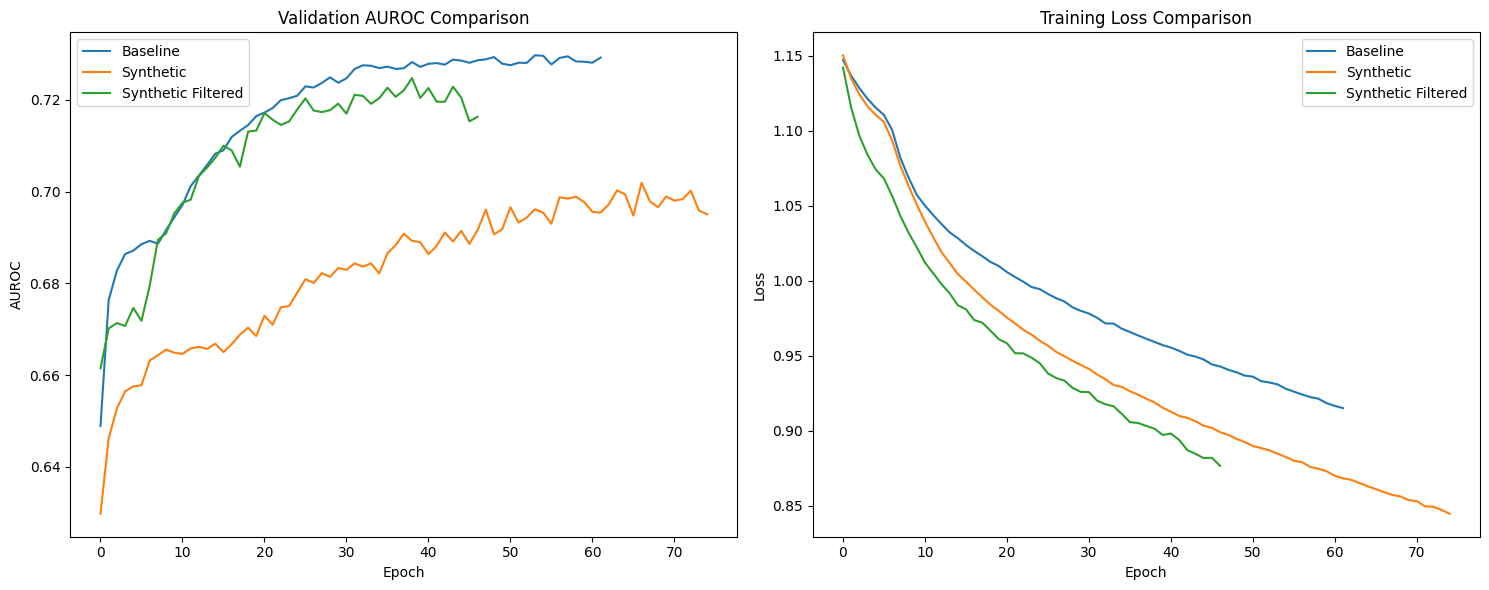

In [9]:
def load_training_logs(path):
    df = pd.read_csv(path)
    return df.groupby('epoch').mean().reset_index()

runs_root = '../classifier/runs'
df_baseline_train = load_training_logs(os.path.join(runs_root, 'baseline_slurm_ref/version_0/metrics.csv'))
df_synthetic_train = load_training_logs(os.path.join(runs_root, 'synthetic_slurm_ref/version_0/metrics.csv'))
df_filtered_train = load_training_logs(os.path.join(runs_root, 'synthetic_filtered_slurm_ref/version_0/metrics.csv'))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].plot(df_baseline_train['epoch'], df_baseline_train['val/auroc'], label='Baseline')
axes[0].plot(df_synthetic_train['epoch'], df_synthetic_train['val/auroc'], label='Synthetic')
axes[0].plot(df_filtered_train['epoch'], df_filtered_train['val/auroc'], label='Synthetic Filtered')
axes[0].set_title('Validation AUROC Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('AUROC')
axes[0].legend()

axes[1].plot(df_baseline_train['epoch'], df_baseline_train['train/loss'], label='Baseline')
axes[1].plot(df_synthetic_train['epoch'], df_synthetic_train['train/loss'], label='Synthetic')
axes[1].plot(df_filtered_train['epoch'], df_filtered_train['train/loss'], label='Synthetic Filtered')
axes[1].set_title('Training Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()